<a href="https://colab.research.google.com/github/EsraaMahmoud09/Market-Basket-Analysis-using-Association-Rules-Apriori-/blob/main/Groceries_Apriori__Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Load Data**

In [91]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
df = pd.read_csv("/content/Groceries_dataset.csv")
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [92]:
import warnings
warnings.filterwarnings("ignore")

In [93]:
df.sample(10)

,Member_number,Date,itemDescription
23894,1837,09-07-2015,yogurt
33477,2817,19-06-2014,bottled water
12927,3837,01-12-2014,newspapers
25300,1504,12-01-2014,white wine
8516,2595,23-01-2015,pastry
26616,4756,10-12-2014,coffee
5501,3925,25-03-2015,turkey
10665,1998,15-02-2014,misc. beverages
85,4293,04-08-2015,coffee
27993,3864,30-12-2014,sliced cheese


In [94]:
df.tail()

,Member_number,Date,itemDescription
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice
38764,1521,26-12-2014,cat food


In [95]:
# number of unique items
num_items = df['itemDescription'].nunique()
print("Number of unique items:", num_items)

# count of each item
item_counts = df['itemDescription'].value_counts()
print(item_counts)

Number of unique items: 167
itemDescription
whole milk               2502
other vegetables         1898
rolls/buns               1716
soda                     1514
yogurt                   1334
                         ... 
rubbing alcohol             5
bags                        4
baby cosmetics              3
kitchen utensil             1
preservation products       1
Name: count, Length: 167, dtype: int64


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


# **Data Cleaning**

In [97]:
# Convert the 'Date' column to datetime
# Replace the format if your dates have a different format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

# Check the conversion
print(df['Date'].head())
print(df.dtypes)

0   2015-07-21
1   2015-01-05
2   2015-09-19
3   2015-12-12
4   2015-02-01
Name: Date, dtype: datetime64[ns]
Member_number               int64
Date               datetime64[ns]
itemDescription            object
dtype: object


In [98]:
df.describe(include="object")

,itemDescription
count,38765
unique,167
top,whole milk
freq,2502


In [99]:
df.shape

(38765, 3)

In [100]:
# 1- Detect duplicate items within each transaction
def has_duplicate_items(item_str):
    items = item_str.split(',')
    return len(items) != len(set(items))

df['DuplicateItems'] = df['itemDescription'].apply(has_duplicate_items)

print("Transactions with duplicate itemDescription:")
print(df[df['DuplicateItems']])

# 2- Detect duplicate transactions (entirely identical items)
# Sort items in each transaction to detect duplicates accurately
df['SortedItems'] = df['itemDescription'].apply(lambda x: ','.join(sorted(x.split(','))))   # لو كانت نفس المعاملة مكتوبة بترتيب مختلف يمكن اكتشاف أنها نفس المعاملة.
duplicate_transactions = df[df.duplicated(subset='SortedItems', keep=False)]

print("\nDuplicate transactions in the dataset:")
print(duplicate_transactions)

# 3- Recommendation
print("\nRecommendation:")
print("- Remove duplicate items within each transaction.")
print("- Check whether duplicate transactions are real or erroneous before removing them.")

Transactions with duplicate itemDescription:
Empty DataFrame
Columns: [Member_number, Date, itemDescription, DuplicateItems]
Index: []

Duplicate transactions in the dataset:
       Member_number       Date        itemDescription  DuplicateItems  \
0               1808 2015-07-21         tropical fruit           False   
1               2552 2015-01-05             whole milk           False   
2               2300 2015-09-19              pip fruit           False   
3               1187 2015-12-12       other vegetables           False   
4               3037 2015-02-01             whole milk           False   
...              ...        ...                    ...             ...   
38760           4471 2014-10-08          sliced cheese           False   
38761           2022 2014-02-23                  candy           False   
38762           1097 2014-04-16               cake bar           False   
38763           1510 2014-12-03  fruit/vegetable juice           False   
38764      

In [101]:
df.isna().sum()

,0
Member_number,0
Date,0
itemDescription,0
DuplicateItems,0
SortedItems,0


In [102]:
# Drop unnecessary columns for Apriori
columns_to_drop = ['DuplicateItems', 'SortedItems']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')  # inplace=True to modify df directly

# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

# Save the cleaned DataFrame to a new CSV
df.to_csv('your_file_cleaned.csv', index=False)

# Verify
print("Columns after cleaning:", df.columns)
print(df.head())
print(df.dtypes)

Columns after cleaning: Index(['Member_number', 'Date', 'itemDescription'], dtype='object')
   Member_number       Date   itemDescription
0           1808 2015-07-21    tropical fruit
1           2552 2015-01-05        whole milk
2           2300 2015-09-19         pip fruit
3           1187 2015-12-12  other vegetables
4           3037 2015-02-01        whole milk
Member_number               int64
Date               datetime64[ns]
itemDescription            object
dtype: object


In [103]:
df.sample(10)

,Member_number,Date,itemDescription
18841,4294,2015-03-02,bottled beer
26845,1432,2014-09-18,long life bakery product
14491,2534,2014-03-29,brown bread
16090,2510,2015-09-29,whole milk
31442,2853,2014-10-26,semi-finished bread
9281,1741,2014-07-12,liver loaf
13710,4297,2014-05-30,other vegetables
12691,1910,2014-10-01,sliced cheese
22771,4091,2015-02-25,whole milk
15813,3927,2015-09-03,other vegetables


# **Implementing Apriori algorithm**

# **Step 1: Importing Required Libraries**

In [104]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
import matplotlib.pyplot as plt
import seaborn as sns

# **Step 2: Group Items by Transaction**

In [105]:
# Group data by Member_number and Date, aggregate items into a list
basket = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()

# Convert the itemDescription column to a list of lists (transactions)
transactions = basket['itemDescription'].tolist()

# Print transactions to see all purchase lists
print(transactions)

[['whole milk', 'pastry', 'salty snack'], ['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['soda', 'pickled vegetables'], ['canned beer', 'misc. beverages'], ['sausage', 'hygiene articles'], ['sausage', 'whole milk', 'rolls/buns'], ['whole milk', 'soda'], ['frankfurter', 'soda', 'whipped/sour cream'], ['beef', 'white bread'], ['frankfurter', 'curd'], ['frozen vegetables', 'other vegetables'], ['butter', 'whole milk'], ['tropical fruit', 'sugar'], ['butter milk', 'specialty chocolate'], ['frozen meals', 'dental care'], ['rolls/buns', 'rolls/buns'], ['root vegetables', 'detergent'], ['sausage', 'rolls/buns'], ['pip fruit', 'whole milk', 'tropical fruit'], ['dish cleaner', 'cling film/bags'], ['rolls/buns', 'red/blush wine', 'chocolate'], ['canned beer', 'frozen fish'], ['other vegetables', 'shopping bags'], ['root vegetables', 'whole milk', 'pastry'], ['whole milk', 'chocolate', 'packaged fruit/vegetables', 'rolls/buns'], ['other vegetables', 'hygiene articles'], ['rolls/buns

# **Step 3: Convert to One-Hot Format**

In [106]:
# 1. Create a TransactionEncoder object to handle transactions
te = TransactionEncoder()

# 2. Fit the encoder to the transactions and transform them into a boolean array
#    Each row represents a transaction; each column represents an item (True if present, False if not)
te_array = te.fit(transactions).transform(transactions)

# 3. Convert the boolean array into a DataFrame with item names as columns
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# **Step 4: Run Apriori Algorithm**

In [107]:
# Add a new column that calculates the number of items in each frequent itemset
# This helps us determine the size (level) of each itemset (e.g., 1-item, 2-item, 3-item sets)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Find the maximum itemset size generated by the Apriori algorithm
# This indicates the highest level (Ck) reached during frequent itemset generation
print("Max level reached (itemset size):", frequent_itemsets['length'].max())

Max level reached (itemset size): 2


 **Output**:
 * Max level reached (itemset size): 2
 * This means the Apriori algorithm generated frequent itemsets up to size 2 (pairs of items),
 * and no frequent itemsets of size 3 or higher were found based on the minimum support threshold.

In [108]:
# Apply the Apriori algorithm to find frequent itemsets
# min_support=0.01 means the itemset must appear in at least 1% of transactions
# use_colnames=True shows item names instead of column indices
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)   #Instead of showing column numbers, it will show product names.

# Print the total number of frequent itemsets discovered
print("Total Frequent Itemsets:", frequent_itemsets.shape[0])     # "69 Frequent Itemsets" = Number of product groups that appeared frequently enough (≥ 1% of transactions)

Total Frequent Itemsets: 69


# **Step 5: Generate Association Rules**

In [109]:
# Generate association rules using confidence as the main metric
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

# Remove rules with empty antecedents or consequents
rules = rules[
    rules['antecedents'].apply(lambda x: len(x) >= 1) &
    rules['consequents'].apply(lambda x: len(x) >= 1)]

# -------------------------------
# Additional Interestingness Metrics
# -------------------------------

# Kulczynski (KULC)
# Measures the average confidence of A→B and B→A
rules['kulc'] = 0.5 * (
    rules['confidence'] +
    (rules['support'] / rules['consequent support']))

# Max Confidence (MaxConf)
# Takes the maximum confidence between A→B and B→A
rules['maxconf'] = np.maximum(
    rules['confidence'],
    rules['support'] / rules['consequent support'])

# All Confidence (AllConf)
# Minimum confidence between A→B and B→A
rules['allconf'] = np.minimum(
    rules['confidence'],
    rules['support'] / rules['consequent support'])

# Jaccard Index
# Measures similarity between itemsets
rules['jaccard'] = rules['support'] / (
    rules['antecedent support'] +
    rules['consequent support'] -
    rules['support'])

# Chi-Square measure
# Evaluates statistical independence between items
rules['chi_square'] = (
    (rules['support'] - (rules['antecedent support'] * rules['consequent support'])) ** 2
) / (rules['antecedent support'] * rules['consequent support'])

# --------------------------------
# Note about Null Invariance
# --------------------------------
# Metrics like Kulc, AllConf, MaxConf, and Jaccard are Null-Invariant.
# This means they are not affected by transactions that contain none
# of the items being analyzed, making them more reliable in large datasets.

# Show results
print("Association Rules:", rules.shape[0])

rules[['antecedents','consequents','support','confidence','lift',
       'kulc','maxconf','allconf','jaccard','chi_square']].head(5)

Association Rules: 4


,antecedents,consequents,support,confidence,lift,kulc,maxconf,allconf,jaccard,chi_square
0,(other vegetables),(whole milk),0.014837,0.121511,0.769430,0.107730,0.121511,0.093948,0.055948,0.001025
1,(rolls/buns),(whole milk),0.013968,0.126974,0.804028,0.107711,0.126974,0.088447,0.055000,0.000667
2,(soda),(whole milk),0.011629,0.119752,0.758296,0.096694,0.119752,0.073635,0.047776,0.000896
3,(yogurt),(whole milk),0.011161,0.129961,0.822940,0.100317,0.129961,0.070673,0.047975,0.000425


# **Step 6: Visualize the Most Popular Items**

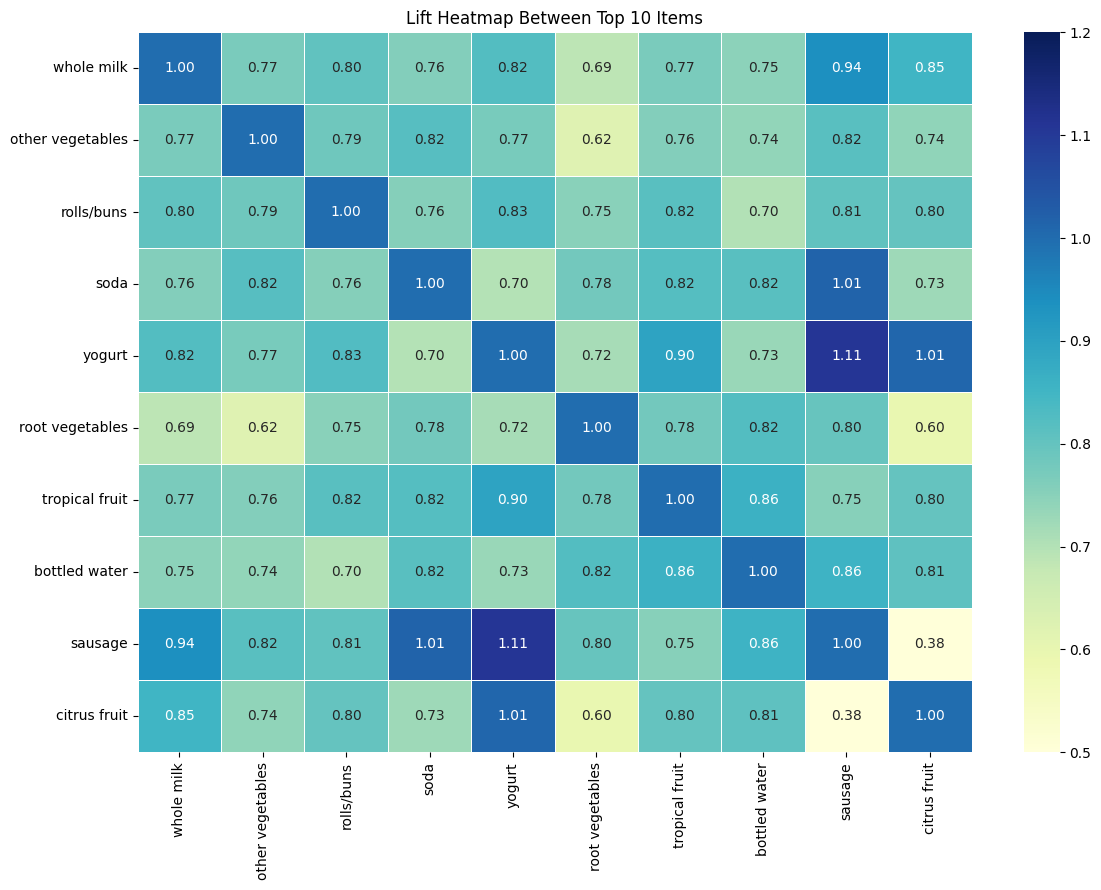

In [110]:
# Get top 10 most purchased items
top_items = df['itemDescription'].value_counts().head(10).index.tolist()

# Group transactions as sets for fast lookup
basket_sets = basket['itemDescription'].apply(set)
total = len(basket_sets)

# Calculate support for each item directly from data
item_support = {}
for item in top_items:
    item_support[item] = basket_sets.apply(lambda x: item in x).sum() / total

# Build lift matrix directly from data (NOT from rules)
# This avoids the bug where missing rules were filled with 1.0
lift_matrix = pd.DataFrame(index=top_items, columns=top_items, dtype=float)

for i in top_items:
    for j in top_items:
        if i == j:
            lift_matrix.loc[i, j] = 1.0
        else:
            pair_sup = basket_sets.apply(lambda x: i in x and j in x).sum() / total
            lift_matrix.loc[i, j] = pair_sup / (item_support[i] * item_support[j])

lift_matrix = lift_matrix.astype(float)

# Plot heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(lift_matrix, annot=True, fmt=".2f", cmap="YlGnBu",
            linewidths=0.5, vmin=0.5, vmax=1.2)
plt.title("Lift Heatmap Between Top 10 Items")
plt.tight_layout()
plt.show()

# **Heatmap of Confidence for Selected Rules**

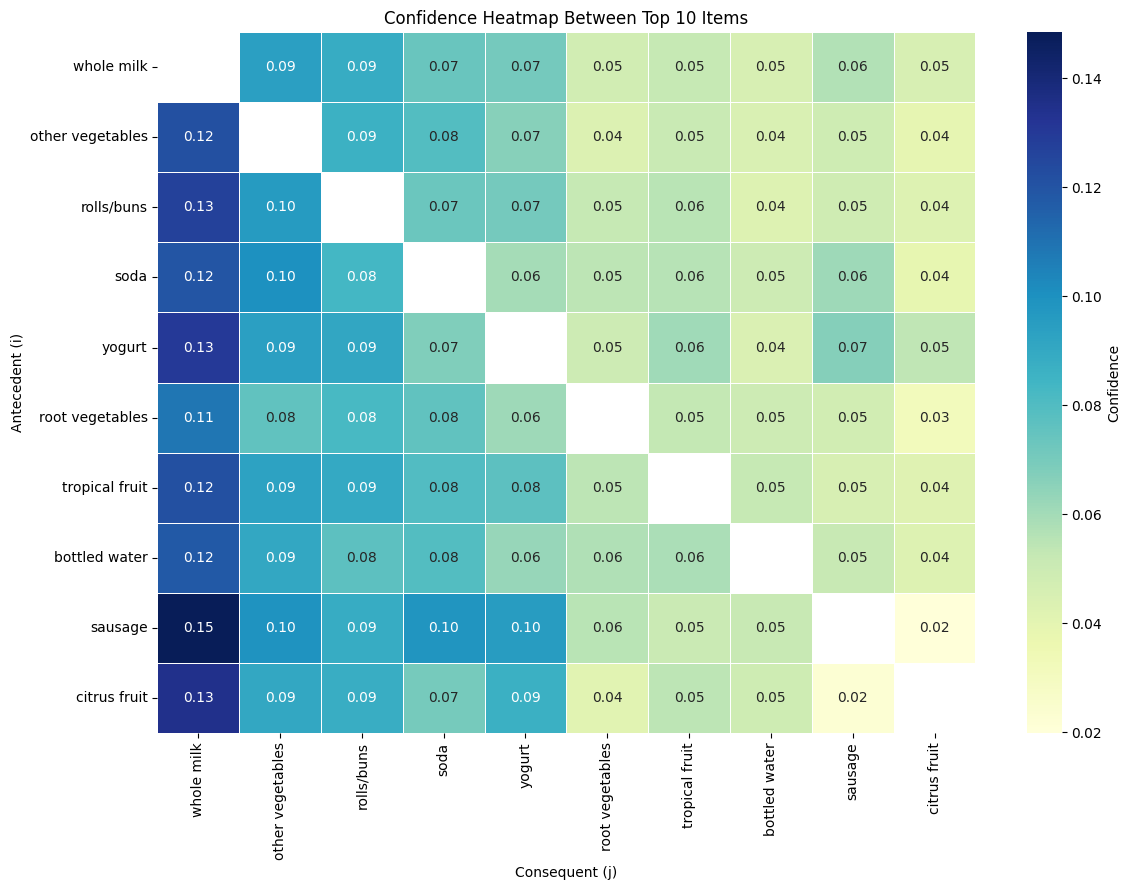

In [111]:
# Build confidence matrix directly from data (NOT from pivot on sparse rules)
# This avoids the bug where most cells were NaN due to missing rules

# Ensure top_items is a list of item names
top_items = df['itemDescription'].value_counts().head(10).index.tolist()

conf_matrix = pd.DataFrame(index=top_items, columns=top_items, dtype=float)

for i in top_items:
    for j in top_items:
        if i == j:
            conf_matrix.loc[i, j] = np.nan  # diagonal
        else:
            # Confidence(i → j) = P(i and j) / P(i)
            pair_sup = basket_sets.apply(lambda x: i in x and j in x).sum() / total
            conf_matrix.loc[i, j] = pair_sup / item_support[i] if item_support[i] > 0 else 0

conf_matrix = conf_matrix.astype(float)

# Plot heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(conf_matrix, annot=True, fmt=".2f", cmap="YlGnBu",
            linewidths=0.5, cbar_kws={'label': 'Confidence'})
plt.title("Confidence Heatmap Between Top 10 Items")
plt.xlabel("Consequent (j)")
plt.ylabel("Antecedent (i)")
plt.tight_layout()
plt.show()

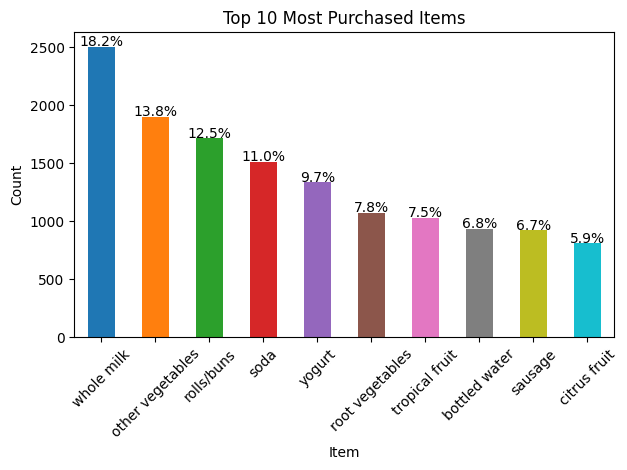

In [112]:
# Get top 10 most purchased items
top_items = df['itemDescription'].value_counts().head(10)

# Calculate percentage relative to total items
percentages = (top_items / top_items.sum()) * 100

# Create different colors for each bar
colors = plt.cm.tab10(np.arange(len(top_items)))

# Plot bar chart
ax = top_items.plot(
    kind='bar',
    color=colors,
    title='Top 10 Most Purchased Items'
)

# Axis labels
plt.xlabel("Item")
plt.ylabel("Count")

# Write percentage above each bar
for i, v in enumerate(top_items):
    ax.text(i, v + 5, f"{percentages.iloc[i]:.1f}%", ha='center', fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()